In [1]:
import tensorflow as tf
print(tf.__version__)


2.14.0


In [2]:
import os
import VGG_help
from VGG_help import prepare_dataset, test_on_data, plot_train_history, plot_confusion_matrix, analyze_performance
from VGG_help import vgg_model, resnet_model, cv_train_and_evaluate_model, train_and_evaluate_model, cv_train_model, cv_train_vgg_model, imbalanced_cv_train_and_evaluate_model, custom_cnn

In [3]:
VGG_help.sns.set_theme()
path_dir = VGG_help.os.getcwd()
VGG_help.np.random.seed(123)
VGG_help.tf.random.set_seed(123)

# Train on Selected Data

In [ ]:
"""

# Defina parâmetros e paths (usando paths absolutos para project_root)
n = 5  # Número de runs
cv = 1  # CV folds (1 para split simples)
epochs = 5  # Epochs (aumente para 10-20 se necessário)
batch_size = 32
input_shape = (128, 128, 3)

# Exemplo para binary (Chest X-Ray: NORMAL/PNEUMONIA)
class_labels = ['NORMAL', 'PNEUMONIA']
num_classes = 2

# Paths absolutos para o seu dataset em project_root (ajuste se necessário)
project_root = r'C:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\project_root'
dataset_dir_train = os.path.join(project_root, 'data', 'train')  # Originais train (70%)
val_dataset_dir = os.path.join(project_root, 'data', 'val')      # Pré-split val (15%)
test_dataset_dir = os.path.join(project_root, 'data', 'test')    # Pré-split test (15%)
dataset_dir_generated = os.path.join(project_root, 'generated', 'train')  # Gerados só para train mix

# Verificação rápida (rode para confirmar)
print("Verificando dataset_dir_train:", dataset_dir_train)
print("Existe?", os.path.exists(dataset_dir_train))
if os.path.exists(dataset_dir_train):
    subfolders = os.listdir(dataset_dir_train)
    print("Subpastas em train:", subfolders)
    for sub in subfolders:
        sub_path = os.path.join(dataset_dir_train, sub)
        if os.path.isdir(sub_path):
            files = [f for f in os.listdir(sub_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"  {sub}: {len(files)} imagens")

print("\nVerificando dataset_dir_generated:", dataset_dir_generated)
print("Existe?", os.path.exists(dataset_dir_generated))
if os.path.exists(dataset_dir_generated):
    subfolders = os.listdir(dataset_dir_generated)
    print("Subpastas em generated/train:", subfolders)
    for sub in subfolders:
        sub_path = os.path.join(dataset_dir_generated, sub)
        if os.path.isdir(sub_path):
            files = [f for f in os.listdir(sub_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"  {sub}: {len(files)} imagens")

print("\nVerificando test_dataset_dir:", test_dataset_dir)
print("Existe?", os.path.exists(test_dataset_dir))
if os.path.exists(test_dataset_dir):
    subfolders = os.listdir(test_dataset_dir)
    print("Subpastas em test:", subfolders)
    for sub in subfolders:
        sub_path = os.path.join(test_dataset_dir, sub)
        if os.path.isdir(sub_path):
            files = [f for f in os.listdir(sub_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"  {sub}: {len(files)} imagens")

"""

Verificando dataset_dir_train: C:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\project_root\data\train
Existe? True
Subpastas em train: ['NORMAL', 'PNEUMONIA']
  NORMAL: 150 imagens
  PNEUMONIA: 100 imagens

Verificando dataset_dir_generated: C:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\project_root\generated\train
Existe? True
Subpastas em generated/train: ['NORMAL', 'PNEUMONIA']
  NORMAL: 400 imagens
  PNEUMONIA: 400 imagens

Verificando test_dataset_dir: C:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\project_root\data\test
Existe? True
Subpastas em test: ['NORMAL', 'PNEUMONIA']
  NORMAL: 25 imagens
  PNEUMONIA: 50 imagens


In [6]:
import os

# ======================================================
# 🔧 Parâmetros principais
# ======================================================
n = 5            # Número de execuções (para média de resultados)
cv = 1           # Cross-validation (1 = simples split)
epochs = 5       # Número de épocas (aumente se necessário)
batch_size = 32
input_shape = (128, 128, 3)

# Classes do problema (exemplo: Chest X-Ray binário)
class_labels = ['NORMAL', 'PNEUMONIA']
num_classes = len(class_labels)

# ======================================================
# 📂 Caminhos dos datasets (somente imagens originais)
# ======================================================
project_root = r'C:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\project_root'

dataset_dir_train = os.path.join(project_root, 'data', 'train')  # 70% treino
val_dataset_dir   = os.path.join(project_root, 'data', 'val')    # 15% validação
test_dataset_dir  = os.path.join(project_root, 'data', 'test')   # 15% teste

# ======================================================
# 🧩 Verificação dos diretórios
# ======================================================
print("🔍 Verificando datasets originais...\n")

for name, path in {
    "Treino": dataset_dir_train,
    "Validação": val_dataset_dir,
    "Teste": test_dataset_dir
}.items():
    print(f"{name} → {path}")
    if os.path.exists(path):
        subfolders = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
        print(f"  ✔️ Existe ({len(subfolders)} classes detectadas): {subfolders}")
        for sub in subfolders:
            sub_path = os.path.join(path, sub)
            files = [
                f for f in os.listdir(sub_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            print(f"     📁 {sub}: {len(files)} imagens")
    else:
        print(f"  ❌ Caminho não encontrado.")
    print("-" * 60)

print("\n✅ Conjuntos carregados: apenas imagens reais de treino, validação e teste.")


🔍 Verificando datasets originais...

Treino → C:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\project_root\data\train
  ✔️ Existe (2 classes detectadas): ['NORMAL', 'PNEUMONIA']
     📁 NORMAL: 150 imagens
     📁 PNEUMONIA: 150 imagens
------------------------------------------------------------
Validação → C:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\project_root\data\val
  ✔️ Existe (2 classes detectadas): ['NORMAL', 'PNEUMONIA']
     📁 NORMAL: 25 imagens
     📁 PNEUMONIA: 25 imagens
------------------------------------------------------------
Teste → C:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\project_root\data\test
  ✔️ Existe (2 classes detectadas): ['NORMAL', 'PNEUMONIA']
     📁 NORMAL: 25 imagens
     📁 PNEUMONIA: 25 imagens
------------------------------------------------------------

✅ Conjuntos carregados: apenas imagens reais de treino, validação e teste.


In [11]:
# Verificação e criação de val (se faltar)
val_dataset_dir = os.path.join(project_root, 'data', 'val')
print(f"\nVerificando val_dataset_dir: {val_dataset_dir}")
if not os.path.exists(val_dataset_dir):
    print("Pasta val não existe – criando...")
    os.makedirs(val_dataset_dir, exist_ok=True)
    # Crie subpastas
    for cls in class_labels:
        os.makedirs(os.path.join(val_dataset_dir, cls), exist_ok=True)
    
    # Split 15% de train para val (estratificado)
    from sklearn.model_selection import train_test_split
    for cls in class_labels:
        cls_path = os.path.join(dataset_dir_train, cls)
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(files) > 0:
            # Split 15% para val (random_state para reprodutibilidade)
            train_files, val_files = train_test_split(files, test_size=0.15, random_state=123)
            # Mova val_files para val/cls
            import shutil
            for f in val_files:
                src = os.path.join(cls_path, f)
                dst = os.path.join(val_dataset_dir, cls, f)
                shutil.move(src, dst)  # Move (ou copy se preferir)
            print(f"  {cls}: Movidas {len(val_files)} para val (restam {len(train_files)} em train)")
        else:
            print(f"  {cls}: Sem imagens para splitar.")
    
    print("Val criada e populada!")
else:
    # Verificação se já existe
    subfolders = os.listdir(val_dataset_dir)
    print("Subpastas em val:", subfolders)
    total_val = 0
    for sub in subfolders:
        sub_path = os.path.join(val_dataset_dir, sub)
        if os.path.isdir(sub_path):
            files = [f for f in os.listdir(sub_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"  {sub}: {len(files)} imagens")
            total_val += len(files)
    print(f"Total em val: {total_val}")

# Atualize vars para usar val pré-split
val_dataset_dir = os.path.join(project_root, 'data', 'val')  # Agora existe


Verificando val_dataset_dir: C:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\project_root\data\val
Subpastas em val: ['NORMAL', 'PNEUMONIA']
  NORMAL: 25 imagens
  PNEUMONIA: 25 imagens
Total em val: 50


### ResNet50 pre-treined

### ResNet50 pre-treined

In [12]:
# ======================================================
# 🔹 Treinamento apenas com imagens reais
# ======================================================

# Listas para coletar métricas (para média e desvio padrão)
metrics_runs = []

title = "ResNet50 on Original Dataset"
file_name = "Trained_Models/ResNet50_training_history_plot_Original"

for i in range(n):
    print(f"\n🚀 Run {i+1}/{n} — Treinamento apenas com dados reais...")

    trained_model, test_metrics, confusion_matrix = cv_train_and_evaluate_model(
        dataset_dir_train=dataset_dir_train,  # 🔹 Train original
        val_dataset_dir=val_dataset_dir,      # 🔹 Validação original
        test_dataset_dir=test_dataset_dir,    # 🔹 Teste original
        class_labels=class_labels,
        model_fn=resnet_model,
        weights="imagenet",
        input_shape=input_shape,
        title=f"{title}_Run{i+1}",
        file_name=f"{file_name}_run{i+1}.png",
        cv=cv,
        epochs=epochs,
        batch_size=batch_size,
        num_classes=num_classes,
        use_mix=False  # 🔴 DESATIVA mistura de dados gerados
        # ❌ Removido o parâmetro generated_dir (não existe mais)
    )

    # 💾 Salva o modelo treinado
    trained_model.save(f'Trained_Models/{title}_run{i+1}.h5')

    # Armazena métricas da execução
    test_metrics['Config'] = 'Original Only'
    test_metrics['Run'] = i + 1
    metrics_runs.append(test_metrics)

    print(f"Run {i+1} Metrics: {test_metrics}")

# ======================================================
# 📊 Análise final (média e desvio padrão)
# ======================================================
df_metrics, comparison = VGG_help.analyze_performance(metrics_runs, output_dir='Trained_Models')



🚀 Run 1/5 — Treinamento apenas com dados reais...
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 13s 878ms/step - loss: 18.3814 - accuracy: 0.6533 - val_loss: 11.3766 - val_accuracy: 0.7600
Epoch 2/5
10/10 [==============================] - 8s 805ms/step - loss: 6.2062 - accuracy: 0.8467 - val_loss: 4.2089 - val_accuracy: 0.8200
Epoch 3/5
10/10 [==============================] - 8s 806ms/step - loss: 3.2987 - accuracy: 0.8900 - val_loss: 4.1548 - val_accuracy: 0.8400
Epoch 4/5
10/10 [==============================] - 8s 848ms/step - loss: 2.0327 - accuracy: 0.8967 - val_loss: 4.4806 - val_accuracy: 0.8600
Epoch 5/5
10/10 [==============================] - 8s 787ms/step - loss: 1.2328 - accuracy: 0.9367 - val_loss: 2.0423 - val_accuracy: 0.8600
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 1]
Debug VGG: len(X_val) = 50, shape = (50, 128, 128, 3)


c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Run 1 Metrics: {'Accuracy': 0.84, 'F1': 0.8397435897435898, 'AUROC': 0.8720000000000001, 'Config': 'Original Only', 'Run': 1}

🚀 Run 2/5 — Treinamento apenas com dados reais...
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 12s 936ms/step - loss: 18.9973 - accuracy: 0.6333 - val_loss: 4.0720 - val_accuracy: 0.8200
Epoch 2/5
10/10 [==============================] - 9s 867ms/step - loss: 1.8740 - accuracy: 0.9100 - val_loss: 6.2393 - val_accuracy: 0.7600
Epoch 3/5
10/10 [==============================] - 8s 854ms/step - loss: 4.4500 - accuracy: 0.8567 - val_loss: 3.7193 - val_accuracy: 0.8600
Epoch 4/5
10/10 [==============================] - 8s 813ms/step - loss: 1.3186 - accuracy: 0.9200 - val_loss: 3.6978 - val_accuracy: 0.8800
Epoch 5/5
10/10 [==============================] - 8s 788ms/step - loss: 0.9550 - accuracy: 0.9433 - val_loss: 2.5533 - val_accuracy: 0.8400
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debu

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Run 2 Metrics: {'Accuracy': 0.78, 'F1': 0.7792051384985951, 'AUROC': 0.8672, 'Config': 'Original Only', 'Run': 2}

🚀 Run 3/5 — Treinamento apenas com dados reais...
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 12s 828ms/step - loss: 19.1425 - accuracy: 0.6933 - val_loss: 2.4739 - val_accuracy: 0.8800
Epoch 2/5
10/10 [==============================] - 7s 751ms/step - loss: 3.8943 - accuracy: 0.8200 - val_loss: 2.8703 - val_accuracy: 0.8800
Epoch 3/5
10/10 [==============================] - 7s 754ms/step - loss: 2.0880 - accuracy: 0.8733 - val_loss: 1.1604 - val_accuracy: 0.9000
Epoch 4/5
10/10 [==============================] - 8s 826ms/step - loss: 0.7968 - accuracy: 0.9400 - val_loss: 1.6562 - val_accuracy: 0.9000
Epoch 5/5
10/10 [==============================] - 8s 762ms/step - loss: 0.1331 - accuracy: 0.9833 - val_loss: 1.5160 - val_accuracy: 0.8800
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y

...

Run 3 Metrics: {'Accuracy': 0.88, 'F1': 0.88, 'AUROC': 0.8952, 'Config': 'Original Only', 'Run': 3}

🚀 Run 4/5 — Treinamento apenas com dados reais...
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 11s 907ms/step - loss: 14.0618 - accuracy: 0.6600 - val_loss: 5.3767 - val_accuracy: 0.8400
Epoch 2/5
10/10 [==============================] - 8s 817ms/step - loss: 4.4577 - accuracy: 0.8600 - val_loss: 3.4425 - val_accuracy: 0.9200
Epoch 3/5
10/10 [==============================] - 8s 829ms/step - loss: 2.8660 - accuracy: 0.8967 - val_loss: 4.3406 - val_accuracy: 0.8800
Epoch 4/5
10/10 [==============================] - 8s 817ms/step - loss: 0.8829 - accuracy: 0.9467 - val_loss: 3.1455 - val_accuracy: 0.8600
Epoch 5/5
10/10 [==============================] - 8s 763ms/step - loss: 0.5425 - accuracy: 0.9500 - val_loss: 3.6545 - val_accuracy: 0.9000
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300,

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Run 4 Metrics: {'Accuracy': 0.8, 'F1': 0.7987117552334944, 'AUROC': 0.9024, 'Config': 'Original Only', 'Run': 4}

🚀 Run 5/5 — Treinamento apenas com dados reais...
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 12s 954ms/step - loss: 24.0018 - accuracy: 0.6367 - val_loss: 25.8976 - val_accuracy: 0.5600
Epoch 2/5
10/10 [==============================] - 8s 814ms/step - loss: 13.3461 - accuracy: 0.7600 - val_loss: 9.0142 - val_accuracy: 0.8400
Epoch 3/5
10/10 [==============================] - 8s 839ms/step - loss: 5.1498 - accuracy: 0.8600 - val_loss: 4.9398 - val_accuracy: 0.8200
Epoch 4/5
10/10 [==============================] - 8s 845ms/step - loss: 2.6233 - accuracy: 0.9133 - val_loss: 5.3643 - val_accuracy: 0.9000
Epoch 5/5
10/10 [==============================] - 8s 812ms/step - loss: 1.1315 - accuracy: 0.9500 - val_loss: 4.0548 - val_accuracy: 0.8200
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Run 5 Metrics: {'Accuracy': 0.84, 'F1': 0.84, 'AUROC': 0.8807999999999999, 'Config': 'Original Only', 'Run': 5}
F1 Mean ± Std (Overall): 0.8275 ± 0.0394

Tabela Comparativa:
          Config  F1_Mean  F1_Std  AUROC_Mean
0  Original Only   0.8275  0.0394      0.8835
Tabela salva em: Trained_Models\performance_comparison.csv
Plot salvo em: Trained_Models\performance_comparison.png



📋 Desempenho do ResNet50 (Original + PGGANs)
            Mean     Std
Accuracy  0.8280  0.0390
F1        0.8275  0.0394
AUROC     0.8835  0.0150

Resumo salvo em: Trained_Models/ResNet50_summary_metrics.csv


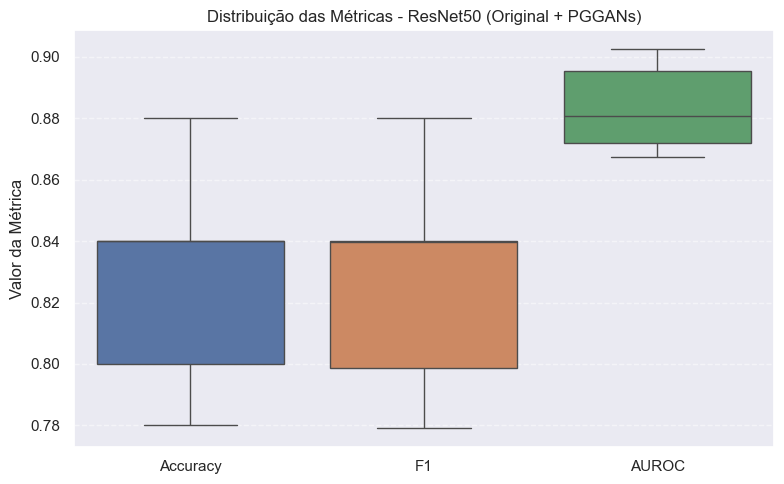

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 🔍 Converte lista de runs em DataFrame
df_metrics = pd.DataFrame(metrics_runs)

# Seleciona apenas colunas relevantes
cols = ['Accuracy', 'F1', 'AUROC', 'Config', 'Run']
df_metrics = df_metrics[[c for c in cols if c in df_metrics.columns]]

# 📈 Calcula média e desvio padrão
summary = df_metrics[['Accuracy', 'F1', 'AUROC']].agg(['mean', 'std']).T
summary.columns = ['Mean', 'Std']
summary = summary.round(4)

print("\n📋 Desempenho do ResNet50 (Original + PGGANs)")
print(summary)

# 💾 Salva resumo
os.makedirs("Trained_Models", exist_ok=True)
summary_path = "Trained_Models/ResNet50_summary_metrics.csv"
summary.to_csv(summary_path)
print(f"\nResumo salvo em: {summary_path}")

# 📊 Visualização
plt.figure(figsize=(8,5))
sns.boxplot(data=df_metrics[['Accuracy', 'F1', 'AUROC']])
plt.title("Distribuição das Métricas - ResNet50 (Original + PGGANs)")
plt.ylabel("Valor da Métrica")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Trained_Models/ResNet50_metrics_boxplot.png", dpi=300)
plt.show()


In [ ]:
# Teste isolado VGG (rode após restart e Cell 5)
print("Testando loading VGG...")
X_train_test, y_train_test = VGG_help.prepare_mixed_dataset(dataset_dir_train, dataset_dir_generated, class_labels, input_shape[:2])
print(f"Loaded train+generated: len = {len(X_train_test)}, shape = {X_train_test.shape if len(X_train_test) > 0 else 'empty'}")
X_val_test, y_val_test = VGG_help.prepare_dataset(val_dataset_dir, class_labels, input_shape[:2])
print(f"Loaded val: len = {len(X_val_test)}, shape = {X_val_test.shape if len(X_val_test) > 0 else 'empty'}")

model_test = vgg_model(input_shape, num_classes=num_classes, weights="imagenet")
print("VGG model created OK (weights loaded)")
print("Teste passado – rode o loop VGG agora. Se falhar aqui, reinstale TF: pip install --upgrade tensorflow")

Testando loading VGG...


TypeError: join() argument must be str, bytes, or os.PathLike object, not 'int'

In [16]:
# ======================================================
# 🧪 Teste isolado com VGG16 — apenas dados reais
# ======================================================
print("🔍 Testando carregamento da VGG com dados reais...")

# 🔹 Carrega apenas o conjunto de treino original
X_train_test, y_train_test = VGG_help.prepare_dataset(
    dataset_dir_train,
    class_labels,
    input_shape[:2]
)
print(f"✅ Loaded train: len = {len(X_train_test)}, shape = {X_train_test.shape if len(X_train_test) > 0 else 'empty'}")

# 🔹 Carrega apenas o conjunto de validação original
X_val_test, y_val_test = VGG_help.prepare_dataset(
    val_dataset_dir,
    class_labels,
    input_shape[:2]
)
print(f"✅ Loaded val: len = {len(X_val_test)}, shape = {X_val_test.shape if len(X_val_test) > 0 else 'empty'}")

# (Opcional) Carregue o conjunto de teste real
# X_test_test, y_test_test = VGG_help.prepare_dataset(test_dataset_dir, class_labels, input_shape[:2])
# print(f"✅ Loaded test: len = {len(X_test_test)}, shape = {X_test_test.shape if len(X_test_test) > 0 else 'empty'}")

# 🔹 Cria o modelo VGG16 normalmente
model_test = vgg_model(input_shape, num_classes=num_classes, weights="imagenet")

print("✅ VGG model created successfully (ImageNet weights loaded)")
print("🎯 Teste passado — pronto para iniciar o loop de treino da VGG.")


🔍 Testando carregamento da VGG com dados reais...
✅ Loaded train: len = 300, shape = (300, 128, 128, 3)
✅ Loaded val: len = 50, shape = (50, 128, 128, 3)
✅ VGG model created successfully (ImageNet weights loaded)
🎯 Teste passado — pronto para iniciar o loop de treino da VGG.


### VGG16 pre-treined

In [19]:
# Treino VGG16 (pré-treinado + mix) - Completo
metrics_runs_vgg = []

title_vgg = "VGG16 on Mixed PGGANs"
file_name_vgg = "Trained_Models/VGG16_training_history_plot_Mixed_PGGANs"

for i in range(n):
    print(f"VGG Run {i+1}/{n}")
    trained_model_vgg, test_metrics_vgg, confusion_matrix_vgg = cv_train_vgg_model(
        dataset_dir_train=dataset_dir_train,
        val_dataset_dir=val_dataset_dir,
        test_dataset_dir=test_dataset_dir,
        class_labels=class_labels,
        input_shape=input_shape,
        title=f"{title_vgg}_Run{i+1}",
        file_name=f"{file_name_vgg}_run{i+1}.png",
        cv=cv,
        epochs=epochs,
        batch_size=batch_size,
        num_classes=num_classes,
        use_mix=True
    )
    
    trained_model_vgg.save(f'Trained_Models/{title_vgg}_run{i+1}.keras')
    
    test_metrics_vgg['Config'] = 'Original+PGGANs'
    test_metrics_vgg['Run'] = i+1
    metrics_runs_vgg.append(test_metrics_vgg)
    print(f"VGG Run {i+1} Metrics: {test_metrics_vgg}")

# Análise VGG
df_metrics_vgg, comparison_vgg = VGG_help.analyze_performance(metrics_runs_vgg, output_dir='Trained_Models')

VGG Run 1/5
VGG - Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
VGG Debug Load: len(X_train_all) = 300, shape = (300, 128, 128, 3)
VGG Debug Split: len(X_train) = 300, unique y_train = [0 1]
VGG Debug Val: len(X_val) = 50, unique y_val = [0 1]
VGG model created OK with imagenet weights
Epoch 1/5
10/10 [==============================] - 10s 941ms/step - loss: 39.0549 - accuracy: 0.6133 - val_loss: 14.1312 - val_accuracy: 0.6200
Epoch 2/5
10/10 [==============================] - 9s 867ms/step - loss: 7.9132 - accuracy: 0.8033 - val_loss: 3.9415 - val_accuracy: 0.8600
Epoch 3/5
10/10 [==============================] - 9s 881ms/step - loss: 3.5412 - accuracy: 0.8900 - val_loss: 2.1068 - val_accuracy: 0.9000
Epoch 4/5
10/10 [==============================] - 9s 953ms/step - loss: 0.8718 - accuracy: 0.9400 - val_loss: 1.9376 - val_accuracy: 0.9000
Epoch 5/5
10/10 [==============================] - 9s 897ms/step - loss: 0.5200 - accuracy: 0.9533 - val_loss: 1.7008 - val_accuracy: 0.88


📋 Desempenho do VGG16 (Original + PGGANs)
            Mean     Std
Accuracy  0.8640  0.0167
F1        0.8639  0.0166
AUROC     0.9214  0.0124

Resumo salvo em: Trained_Models/VGG16_summary_metrics.csv


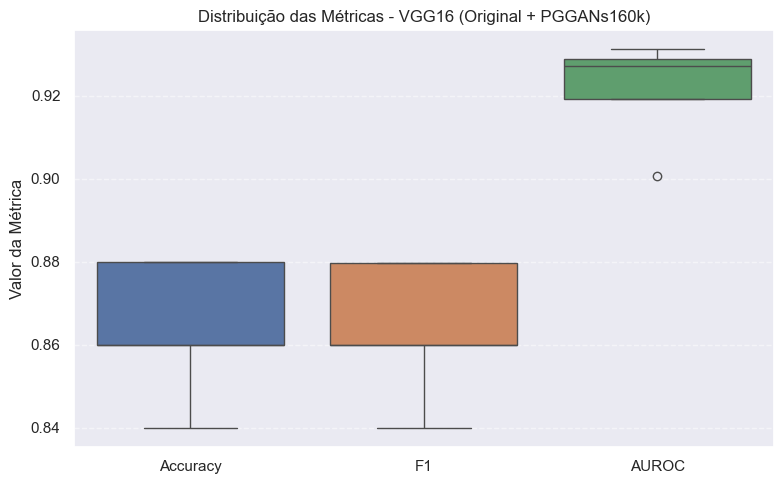

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 🔍 Converte lista de runs em DataFrame
df_metrics_vgg = pd.DataFrame(metrics_runs_vgg)

# Seleciona apenas colunas relevantes (garante que existam)
cols = ['Accuracy', 'F1', 'AUROC', 'Config', 'Run']
df_metrics_vgg = df_metrics_vgg[[c for c in cols if c in df_metrics_vgg.columns]]

# 📈 Calcula média e desvio padrão
summary_vgg = df_metrics_vgg[['Accuracy', 'F1', 'AUROC']].agg(['mean', 'std']).T
summary_vgg.columns = ['Mean', 'Std']
summary_vgg = summary_vgg.round(4)

print("\n📋 Desempenho do VGG16 (Original + PGGANs)")
print(summary_vgg)

# 💾 Salva resumo em CSV
os.makedirs("Trained_Models", exist_ok=True)
summary_path_vgg = "Trained_Models/VGG16_summary_metrics.csv"
summary_vgg.to_csv(summary_path_vgg)
print(f"\nResumo salvo em: {summary_path_vgg}")

# 📊 Visualização (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(data=df_metrics_vgg[['Accuracy', 'F1', 'AUROC']])
plt.title("Distribuição das Métricas - VGG16 (Original + PGGANs160k)")
plt.ylabel("Valor da Métrica")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 💾 Salva gráfico
plt.savefig("Trained_Models/VGG16_metrics_boxplot.png", dpi=300)
plt.show()


#### CNN Without trainning

In [21]:
# Treino Custom CNN (de zero + mix)
metrics_runs_cnn = []

title_cnn = "CustomCNN on Mixed PGGANs160k"
file_name_cnn = "Trained_Models/CustomCNN_training_history_plot_Mixed_PGGANs160k"

for i in range(n):
    print(f"CNN Run {i+1}/{n}")
    trained_model_cnn, test_metrics_cnn, confusion_matrix_cnn = cv_train_and_evaluate_model(
        dataset_dir_train=dataset_dir_train,
        val_dataset_dir=val_dataset_dir,
        test_dataset_dir=test_dataset_dir,
        class_labels=class_labels,
        model_fn=custom_cnn,  # Custom CNN
         weights=None,  # Sem pré-treino
        input_shape=input_shape,
        title=f"{title_cnn}_Run{i+1}",
        file_name=f"{file_name_cnn}_run{i+1}.png",
        cv=cv,
        epochs=epochs,
        batch_size=batch_size,
        num_classes=num_classes,
        use_mix=True
    )
    
    trained_model_cnn.save(f'Trained_Models/{title_cnn}_run{i+1}.h5')
    
    test_metrics_cnn['Config'] = 'Original+PGGANs'
    test_metrics_cnn['Run'] = i+1
    metrics_runs_cnn.append(test_metrics_cnn)
    print(f"CNN Run {i+1} Metrics: {test_metrics_cnn}")

# Análise CNN
df_metrics_cnn, comparison_cnn = VGG_help.analyze_performance(metrics_runs_cnn, output_dir='Trained_Models')

CNN Run 1/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 22s 2s/step - loss: 3.3156 - accuracy: 0.6067 - val_loss: 1.0894 - val_accuracy: 0.8000
Epoch 2/5
10/10 [==============================] - 16s 2s/step - loss: 1.5206 - accuracy: 0.7767 - val_loss: 0.9174 - val_accuracy: 0.9200
Epoch 3/5
10/10 [==============================] - 16s 2s/step - loss: 1.1012 - accuracy: 0.8833 - val_loss: 0.8782 - val_accuracy: 0.9400
Epoch 4/5
10/10 [==============================] - 15s 2s/step - loss: 0.9493 - accuracy: 0.9233 - val_loss: 1.1334 - val_accuracy: 0.8200
Epoch 5/5
10/10 [==============================] - 16s 2s/step - loss: 0.8732 - accuracy: 0.9267 - val_loss: 1.0036 - val_accuracy: 0.9000
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 1]
Debug VGG: len(X_val) = 50, shape = (50, 128, 128, 3)


c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


CNN Run 1 Metrics: {'Accuracy': 0.78, 'F1': 0.7792051384985951, 'AUROC': 0.864, 'Config': 'Original+PGGANs', 'Run': 1}
CNN Run 2/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 17s 2s/step - loss: 2.4439 - accuracy: 0.6233 - val_loss: 0.9293 - val_accuracy: 0.9200
Epoch 2/5
10/10 [==============================] - 16s 2s/step - loss: 1.5483 - accuracy: 0.8067 - val_loss: 0.9480 - val_accuracy: 0.9000
Epoch 3/5
10/10 [==============================] - 15s 2s/step - loss: 1.1058 - accuracy: 0.8833 - val_loss: 0.9327 - val_accuracy: 0.8800
Epoch 4/5
10/10 [==============================] - 15s 2s/step - loss: 0.9060 - accuracy: 0.9000 - val_loss: 0.8257 - val_accuracy: 0.9600
Epoch 5/5
10/10 [==============================] - 15s 1s/step - loss: 1.0806 - accuracy: 0.8767 - val_loss: 0.7968 - val_accuracy: 0.9800
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 1]
Debug VG

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


CNN Run 2 Metrics: {'Accuracy': 0.78, 'F1': 0.7792051384985951, 'AUROC': 0.8847999999999999, 'Config': 'Original+PGGANs', 'Run': 2}
CNN Run 3/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 17s 2s/step - loss: 2.2737 - accuracy: 0.6767 - val_loss: 2.2694 - val_accuracy: 0.5400
Epoch 2/5
10/10 [==============================] - 16s 2s/step - loss: 1.4904 - accuracy: 0.7833 - val_loss: 1.8338 - val_accuracy: 0.5800
Epoch 3/5
10/10 [==============================] - 16s 2s/step - loss: 1.2757 - accuracy: 0.8700 - val_loss: 1.0695 - val_accuracy: 0.8800
Epoch 4/5
10/10 [==============================] - 15s 1s/step - loss: 0.9229 - accuracy: 0.9267 - val_loss: 0.7795 - val_accuracy: 0.9800
Epoch 5/5
10/10 [==============================] - 15s 1s/step - loss: 0.8752 - accuracy: 0.9267 - val_loss: 0.8215 - val_accuracy: 0.9000
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [

...

CNN Run 3 Metrics: {'Accuracy': 0.88, 'F1': 0.8798076923076923, 'AUROC': 0.928, 'Config': 'Original+PGGANs', 'Run': 3}
CNN Run 4/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 17s 2s/step - loss: 2.8608 - accuracy: 0.6400 - val_loss: 3.8305 - val_accuracy: 0.5000
Epoch 2/5
10/10 [==============================] - 15s 1s/step - loss: 1.2163 - accuracy: 0.8400 - val_loss: 1.1900 - val_accuracy: 0.8000
Epoch 3/5
10/10 [==============================] - 14s 1s/step - loss: 1.0748 - accuracy: 0.8900 - val_loss: 1.1408 - val_accuracy: 0.8000
Epoch 4/5
10/10 [==============================] - 15s 1s/step - loss: 1.0816 - accuracy: 0.8967 - val_loss: 1.0973 - val_accuracy: 0.8800
Epoch 5/5
10/10 [==============================] - 15s 1s/step - loss: 0.8632 - accuracy: 0.9433 - val_loss: 1.1446 - val_accuracy: 0.8400
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 1]
Debug VG

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


CNN Run 4 Metrics: {'Accuracy': 0.66, 'F1': 0.6263736263736264, 'AUROC': 0.8560000000000001, 'Config': 'Original+PGGANs', 'Run': 4}
CNN Run 5/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 17s 2s/step - loss: 2.1028 - accuracy: 0.6367 - val_loss: 3.6041 - val_accuracy: 0.5000
Epoch 2/5
10/10 [==============================] - 14s 1s/step - loss: 1.3937 - accuracy: 0.8167 - val_loss: 1.7772 - val_accuracy: 0.6000
Epoch 3/5
10/10 [==============================] - 16s 2s/step - loss: 1.0150 - accuracy: 0.8800 - val_loss: 0.9933 - val_accuracy: 0.8800
Epoch 4/5
10/10 [==============================] - 16s 2s/step - loss: 0.8434 - accuracy: 0.9333 - val_loss: 1.1234 - val_accuracy: 0.8200
Epoch 5/5
10/10 [==============================] - 14s 1s/step - loss: 0.8410 - accuracy: 0.9467 - val_loss: 1.1343 - val_accuracy: 0.8200
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


CNN Run 5 Metrics: {'Accuracy': 0.72, 'F1': 0.7083333333333335, 'AUROC': 0.8432000000000001, 'Config': 'Original+PGGANs', 'Run': 5}
F1 Mean ± Std (Overall): 0.7546 ± 0.0942

Tabela Comparativa:
            Config  F1_Mean  F1_Std  AUROC_Mean
0  Original+PGGANs   0.7546  0.0942      0.8752
Tabela salva em: Trained_Models\performance_comparison.csv
Plot salvo em: Trained_Models\performance_comparison.png



📋 Desempenho do Custom CNN (Original + PGGANs160k)
            Mean     Std
Accuracy  0.7640  0.0817
F1        0.7546  0.0942
AUROC     0.8752  0.0332

Resumo salvo em: Trained_Models/CustomCNN_summary_metrics.csv


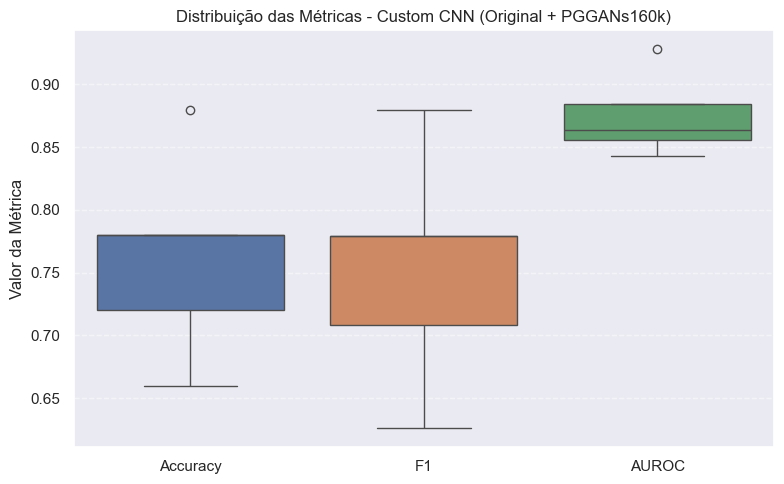

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 🔍 Converte lista de execuções em DataFrame
df_metrics_cnn = pd.DataFrame(metrics_runs_cnn)

# Seleciona apenas colunas relevantes
cols = ['Accuracy', 'F1', 'AUROC', 'Config', 'Run']
df_metrics_cnn = df_metrics_cnn[[c for c in cols if c in df_metrics_cnn.columns]]

# 📈 Calcula média e desvio padrão
summary_cnn = df_metrics_cnn[['Accuracy', 'F1', 'AUROC']].agg(['mean', 'std']).T
summary_cnn.columns = ['Mean', 'Std']
summary_cnn = summary_cnn.round(4)

print("\n📋 Desempenho do Custom CNN (Original + PGGANs160k)")
print(summary_cnn)

# 💾 Salva resumo em CSV
os.makedirs("Trained_Models", exist_ok=True)
summary_path_cnn = "Trained_Models/CustomCNN_summary_metrics.csv"
summary_cnn.to_csv(summary_path_cnn)
print(f"\nResumo salvo em: {summary_path_cnn}")

# 📊 Visualização (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(data=df_metrics_cnn[['Accuracy', 'F1', 'AUROC']])
plt.title("Distribuição das Métricas - Custom CNN (Original + PGGANs160k)")
plt.ylabel("Valor da Métrica")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 💾 Salva gráfico
plt.savefig("Trained_Models/CustomCNN_metrics_boxplot.png", dpi=300)
plt.show()


####  DenseNet121 pre-treined

In [9]:
# Treino DenseNet121 (pré-treinado + mix)
metrics_runs_densenet = []

title_densenet = "DenseNet121 on Mixed PGGANs160k"
file_name_densenet = "Trained_Models/DenseNet121_training_history_plot_Mixed"

for i in range(n):
    print(f"DenseNet Run {i+1}/{n}")
    trained_model_densenet, test_metrics_densenet, confusion_matrix_densenet = VGG_help.cv_train_and_evaluate_model(
        dataset_dir_train=dataset_dir_train,   # Conjunto de treino original
        val_dataset_dir=val_dataset_dir,       # Conjunto de validação
        test_dataset_dir=test_dataset_dir,     # Conjunto de teste
        class_labels=class_labels,
        model_fn=VGG_help.build_densenet_model,  # Função DenseNet definida no VGG_help.py
        weights="imagenet",                     # Usa pesos pré-treinados
        input_shape=input_shape,                # Ex.: (128, 128, 3)
        title=f"{title_densenet}_Run{i+1}",
        file_name=f"{file_name_densenet}_run{i+1}.png",
        cv=cv,
        epochs=epochs,
        batch_size=batch_size,
        num_classes=num_classes,
        use_mix=True
    )

    # Salvar modelo treinado
    trained_model_densenet.save(f'Trained_Models/{title_densenet}_run{i+1}.h5')

    # Adiciona métricas com tags de configuração
    test_metrics_densenet['Config'] = 'Original+PGGANs'
    test_metrics_densenet['Run'] = i + 1
    metrics_runs_densenet.append(test_metrics_densenet)

    print(f"DenseNet Run {i+1} Metrics: {test_metrics_densenet}")

# Análise final DenseNet
df_metrics_densenet, comparison_densenet = VGG_help.analyze_performance(metrics_runs_densenet, output_dir='Trained_Models')


DenseNet Run 1/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 78s 4s/step - loss: 0.8574 - accuracy: 0.7200 - val_loss: 2.4647 - val_accuracy: 0.5400
Epoch 2/5
10/10 [==============================] - 37s 4s/step - loss: 0.3610 - accuracy: 0.8800 - val_loss: 1.4365 - val_accuracy: 0.6000
Epoch 3/5
10/10 [==============================] - 36s 4s/step - loss: 0.3091 - accuracy: 0.8967 - val_loss: 8.8153 - val_accuracy: 0.5000
Epoch 4/5
10/10 [==============================] - 35s 3s/step - loss: 0.1809 - accuracy: 0.9367 - val_loss: 7.9427 - val_accuracy: 0.5200
Epoch 5/5
10/10 [==============================] - 35s 3s/step - loss: 0.0439 - accuracy: 0.9800 - val_loss: 12.8400 - val_accuracy: 0.5000
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 1]
Debug VGG: len(X_val) = 50, shape = (50, 128, 128, 3)


c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

DenseNet Run 1 Metrics: {'Accuracy': 0.5, 'F1': 0.33333333333333326, 'AUROC': 0.912, 'Config': 'Original+PGGANs', 'Run': 1}
DenseNet Run 2/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 58s 4s/step - loss: 0.7404 - accuracy: 0.7500 - val_loss: 5.4674 - val_accuracy: 0.5000
Epoch 2/5
10/10 [==============================] - 34s 3s/step - loss: 0.3394 - accuracy: 0.8767 - val_loss: 11.9411 - val_accuracy: 0.5000
Epoch 3/5
10/10 [==============================] - 33s 3s/step - loss: 0.2430 - accuracy: 0.9333 - val_loss: 5.4242 - val_accuracy: 0.5800
Epoch 4/5
10/10 [==============================] - 33s 3s/step - loss: 0.0855 - accuracy: 0.9667 - val_loss: 1.9902 - val_accuracy: 0.6800
Epoch 5/5
10/10 [==============================] - 33s 3s/step - loss: 0.0845 - accuracy: 0.9733 - val_loss: 4.8237 - val_accuracy: 0.5400
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


DenseNet Run 2 Metrics: {'Accuracy': 0.52, 'F1': 0.4906621392190152, 'AUROC': 0.6032, 'Config': 'Original+PGGANs', 'Run': 2}
DenseNet Run 3/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 61s 4s/step - loss: 0.8112 - accuracy: 0.7467 - val_loss: 14.6988 - val_accuracy: 0.5000
Epoch 2/5
10/10 [==============================] - 35s 3s/step - loss: 0.2630 - accuracy: 0.9000 - val_loss: 208.5105 - val_accuracy: 0.5000
Epoch 3/5
10/10 [==============================] - 35s 3s/step - loss: 0.1507 - accuracy: 0.9400 - val_loss: 18.9440 - val_accuracy: 0.5400
Epoch 4/5
10/10 [==============================] - 33s 3s/step - loss: 0.1861 - accuracy: 0.9233 - val_loss: 10.5225 - val_accuracy: 0.5400
Epoch 5/5
10/10 [==============================] - 33s 3s/step - loss: 0.0856 - accuracy: 0.9767 - val_loss: 9.7879 - val_accuracy: 0.5000
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes 

...

DenseNet Run 3 Metrics: {'Accuracy': 0.5, 'F1': 0.39290917921321034, 'AUROC': 0.7136, 'Config': 'Original+PGGANs', 'Run': 3}
DenseNet Run 4/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 68s 4s/step - loss: 0.6553 - accuracy: 0.7667 - val_loss: 5.9812 - val_accuracy: 0.5000
Epoch 2/5
10/10 [==============================] - 34s 3s/step - loss: 0.2967 - accuracy: 0.8933 - val_loss: 5.7202 - val_accuracy: 0.5000
Epoch 3/5
10/10 [==============================] - 34s 3s/step - loss: 0.2130 - accuracy: 0.9267 - val_loss: 1.3315 - val_accuracy: 0.6600
Epoch 4/5
10/10 [==============================] - 35s 3s/step - loss: 0.0933 - accuracy: 0.9733 - val_loss: 3.3017 - val_accuracy: 0.6000
Epoch 5/5
10/10 [==============================] - 34s 3s/step - loss: 0.0907 - accuracy: 0.9600 - val_loss: 2.4041 - val_accuracy: 0.7800
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


DenseNet Run 4 Metrics: {'Accuracy': 0.62, 'F1': 0.5558672276764844, 'AUROC': 0.8944, 'Config': 'Original+PGGANs', 'Run': 4}
DenseNet Run 5/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 69s 4s/step - loss: 0.6933 - accuracy: 0.7600 - val_loss: 0.8748 - val_accuracy: 0.6800
Epoch 2/5
10/10 [==============================] - 36s 4s/step - loss: 0.4440 - accuracy: 0.8633 - val_loss: 9.4398 - val_accuracy: 0.5000
Epoch 3/5
10/10 [==============================] - 35s 4s/step - loss: 0.1014 - accuracy: 0.9733 - val_loss: 21.8993 - val_accuracy: 0.5000
Epoch 4/5
10/10 [==============================] - 35s 4s/step - loss: 0.0820 - accuracy: 0.9633 - val_loss: 4.0268 - val_accuracy: 0.6000
Epoch 5/5
10/10 [==============================] - 34s 3s/step - loss: 0.0571 - accuracy: 0.9867 - val_loss: 1.0211 - val_accuracy: 0.8600
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


DenseNet Run 5 Metrics: {'Accuracy': 0.74, 'F1': 0.726775956284153, 'AUROC': 0.904, 'Config': 'Original+PGGANs', 'Run': 5}
F1 Mean ± Std (Overall): 0.4999 ± 0.1532

Tabela Comparativa:
            Config  F1_Mean  F1_Std  AUROC_Mean
0  Original+PGGANs   0.4999  0.1532      0.8054
Tabela salva em: Trained_Models\performance_comparison.csv
Plot salvo em: Trained_Models\performance_comparison.png



📋 Desempenho do DenseNet121 (Original + PGGANs160k)
            Mean     Std
Accuracy  0.5760  0.1043
F1        0.4999  0.1532
AUROC     0.8054  0.1399

Resumo salvo em: Trained_Models/DenseNet121_summary_metrics.csv


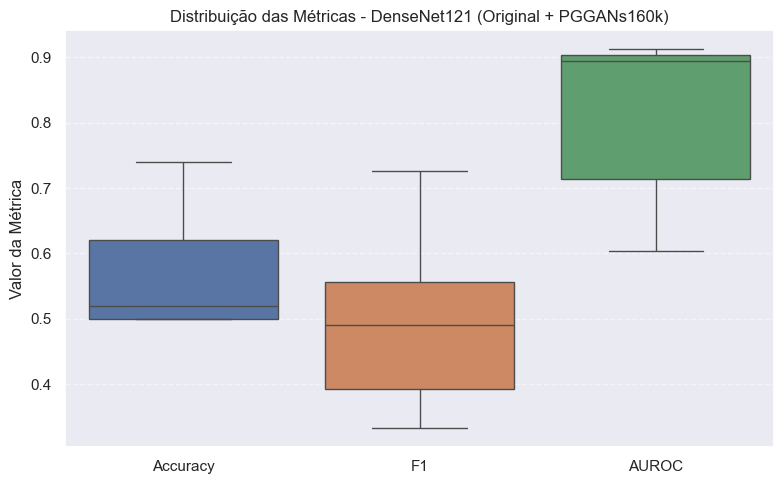

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 🔍 Converte lista de execuções em DataFrame
df_metrics_densenet = pd.DataFrame(metrics_runs_densenet)

# Seleciona apenas colunas relevantes
cols = ['Accuracy', 'F1', 'AUROC', 'Config', 'Run']
df_metrics_densenet = df_metrics_densenet[[c for c in cols if c in df_metrics_densenet.columns]]

# 📈 Calcula média e desvio padrão
summary_densenet = df_metrics_densenet[['Accuracy', 'F1', 'AUROC']].agg(['mean', 'std']).T
summary_densenet.columns = ['Mean', 'Std']
summary_densenet = summary_densenet.round(4)

print("\n📋 Desempenho do DenseNet121 (Original + PGGANs160k)")
print(summary_densenet)

# 💾 Salva resumo em CSV
os.makedirs("Trained_Models", exist_ok=True)
summary_path_densenet = "Trained_Models/DenseNet121_summary_metrics.csv"
summary_densenet.to_csv(summary_path_densenet)
print(f"\nResumo salvo em: {summary_path_densenet}")

# 📊 Visualização (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(data=df_metrics_densenet[['Accuracy', 'F1', 'AUROC']])
plt.title("Distribuição das Métricas - DenseNet121 (Original + PGGANs160k)")
plt.ylabel("Valor da Métrica")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 💾 Salva gráfico
plt.savefig("Trained_Models/DenseNet121_metrics_boxplot.png", dpi=300)
plt.show()


#### Xception Model pre-treined + mix

In [27]:
# Treino Xception (pré-treinado + mix)
metrics_runs_xception = []

title_xception = "Xception on Mixed PGGANs"
file_name_xception = "Trained_Models/Xception_training_history_plot_Mixed"

for i in range(n):
    print(f"Xception Run {i+1}/{n}")
    trained_model_xception, test_metrics_xception, confusion_matrix_xception = VGG_help.cv_train_and_evaluate_model(
        dataset_dir_train=dataset_dir_train,     # Treino original
        val_dataset_dir=val_dataset_dir,         # Validação
        test_dataset_dir=test_dataset_dir,       # Teste
        class_labels=class_labels,
        model_fn=VGG_help.build_xception_model,  # Função no VGG_help.py
        weights="imagenet",                      # Usa pesos pré-treinados
        input_shape=input_shape,                 # Ex.: (128, 128, 3)
        title=f"{title_xception}_Run{i+1}",
        file_name=f"{file_name_xception}_run{i+1}.png",
        cv=cv,
        epochs=epochs,
        batch_size=batch_size,
        num_classes=num_classes,
        use_mix=True
    )

    # Salvar modelo treinado
    trained_model_xception.save(f'Trained_Models/{title_xception}_run{i+1}.h5')

    # Adiciona métricas com informações da execução
    test_metrics_xception['Config'] = 'Original+PGGANs'
    test_metrics_xception['Run'] = i + 1
    metrics_runs_xception.append(test_metrics_xception)

    print(f"Xception Run {i+1} Metrics: {test_metrics_xception}")

# Análise final Xception (média ± desvio padrão)
df_metrics_xception, comparison_xception = VGG_help.analyze_performance(metrics_runs_xception, output_dir='Trained_Models')


Xception Run 1/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 50s 3s/step - loss: 0.4646 - accuracy: 0.7633 - val_loss: 10.3890 - val_accuracy: 0.5000
Epoch 2/5
10/10 [==============================] - 31s 3s/step - loss: 0.3201 - accuracy: 0.8833 - val_loss: 1.8689 - val_accuracy: 0.6000
Epoch 3/5
10/10 [==============================] - 31s 3s/step - loss: 0.1546 - accuracy: 0.9367 - val_loss: 0.7037 - val_accuracy: 0.7000
Epoch 4/5
10/10 [==============================] - 31s 3s/step - loss: 0.0890 - accuracy: 0.9733 - val_loss: 1.1922 - val_accuracy: 0.8400
Epoch 5/5
10/10 [==============================] - 30s 3s/step - loss: 0.0379 - accuracy: 0.9833 - val_loss: 0.9960 - val_accuracy: 0.8200
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 1]
Debug VGG: len(X_val) = 50, shape = (50, 128, 128, 3)


c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Xception Run 1 Metrics: {'Accuracy': 0.72, 'F1': 0.7126436781609194, 'AUROC': 0.8896, 'Config': 'Original+PGGANs', 'Run': 1}
Xception Run 2/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 46s 3s/step - loss: 0.5273 - accuracy: 0.7600 - val_loss: 3.2802 - val_accuracy: 0.5600
Epoch 2/5
10/10 [==============================] - 30s 3s/step - loss: 0.1911 - accuracy: 0.9433 - val_loss: 3.2261 - val_accuracy: 0.8000
Epoch 3/5
10/10 [==============================] - 30s 3s/step - loss: 0.1579 - accuracy: 0.9467 - val_loss: 7.4180 - val_accuracy: 0.5200
Epoch 4/5
10/10 [==============================] - 30s 3s/step - loss: 0.1075 - accuracy: 0.9567 - val_loss: 8.2752 - val_accuracy: 0.5200
Epoch 5/5
10/10 [==============================] - 30s 3s/step - loss: 0.0320 - accuracy: 0.9900 - val_loss: 13.4599 - val_accuracy: 0.5400
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Xception Run 2 Metrics: {'Accuracy': 0.56, 'F1': 0.45436507936507936, 'AUROC': 0.888, 'Config': 'Original+PGGANs', 'Run': 2}
Xception Run 3/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 68s 3s/step - loss: 0.5184 - accuracy: 0.7600 - val_loss: 4.0355 - val_accuracy: 0.5400
Epoch 2/5
10/10 [==============================] - 31s 3s/step - loss: 0.2810 - accuracy: 0.8700 - val_loss: 18.8515 - val_accuracy: 0.5200
Epoch 3/5
10/10 [==============================] - 33s 3s/step - loss: 0.2016 - accuracy: 0.9333 - val_loss: 9.1926 - val_accuracy: 0.6600
Epoch 4/5
10/10 [==============================] - 31s 3s/step - loss: 0.1361 - accuracy: 0.9433 - val_loss: 6.6603 - val_accuracy: 0.7400
Epoch 5/5
10/10 [==============================] - 30s 3s/step - loss: 0.0864 - accuracy: 0.9700 - val_loss: 6.5846 - val_accuracy: 0.7000
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0

...

Xception Run 3 Metrics: {'Accuracy': 0.7, 'F1': 0.6703296703296704, 'AUROC': 0.8959999999999999, 'Config': 'Original+PGGANs', 'Run': 3}
Xception Run 4/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 47s 3s/step - loss: 0.6512 - accuracy: 0.6867 - val_loss: 0.5921 - val_accuracy: 0.6600
Epoch 2/5
10/10 [==============================] - 29s 3s/step - loss: 0.6023 - accuracy: 0.7933 - val_loss: 11.8558 - val_accuracy: 0.5000
Epoch 3/5
10/10 [==============================] - 31s 3s/step - loss: 0.3652 - accuracy: 0.8233 - val_loss: 12.4252 - val_accuracy: 0.5000
Epoch 4/5
10/10 [==============================] - 30s 3s/step - loss: 0.1384 - accuracy: 0.9500 - val_loss: 5.9791 - val_accuracy: 0.6400
Epoch 5/5
10/10 [==============================] - 27s 3s/step - loss: 0.1267 - accuracy: 0.9367 - val_loss: 2.4029 - val_accuracy: 0.6800
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique 

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Xception Run 4 Metrics: {'Accuracy': 0.66, 'F1': 0.6353496353496354, 'AUROC': 0.9039999999999999, 'Config': 'Original+PGGANs', 'Run': 4}
Xception Run 5/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 41s 3s/step - loss: 0.5063 - accuracy: 0.7800 - val_loss: 17.2164 - val_accuracy: 0.5000
Epoch 2/5
10/10 [==============================] - 29s 3s/step - loss: 0.3286 - accuracy: 0.8733 - val_loss: 6.0954 - val_accuracy: 0.7000
Epoch 3/5
10/10 [==============================] - 32s 3s/step - loss: 0.1439 - accuracy: 0.9467 - val_loss: 3.4176 - val_accuracy: 0.8000
Epoch 4/5
10/10 [==============================] - 28s 3s/step - loss: 0.0308 - accuracy: 0.9933 - val_loss: 4.5840 - val_accuracy: 0.7400
Epoch 5/5
10/10 [==============================] - 27s 3s/step - loss: 0.0375 - accuracy: 0.9933 - val_loss: 3.1012 - val_accuracy: 0.8000
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique 

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Xception Run 5 Metrics: {'Accuracy': 0.8, 'F1': 0.7916666666666667, 'AUROC': 0.9568, 'Config': 'Original+PGGANs', 'Run': 5}
F1 Mean ± Std (Overall): 0.6529 ± 0.1254

Tabela Comparativa:
            Config  F1_Mean  F1_Std  AUROC_Mean
0  Original+PGGANs   0.6529  0.1254      0.9069
Tabela salva em: Trained_Models\performance_comparison.csv
Plot salvo em: Trained_Models\performance_comparison.png



📋 Desempenho do Xception (Original + PGGANs160k)
            Mean     Std
Accuracy  0.6880  0.0879
F1        0.6529  0.1254
AUROC     0.9069  0.0286

Resumo salvo em: Trained_Models/Xception_summary_metrics.csv


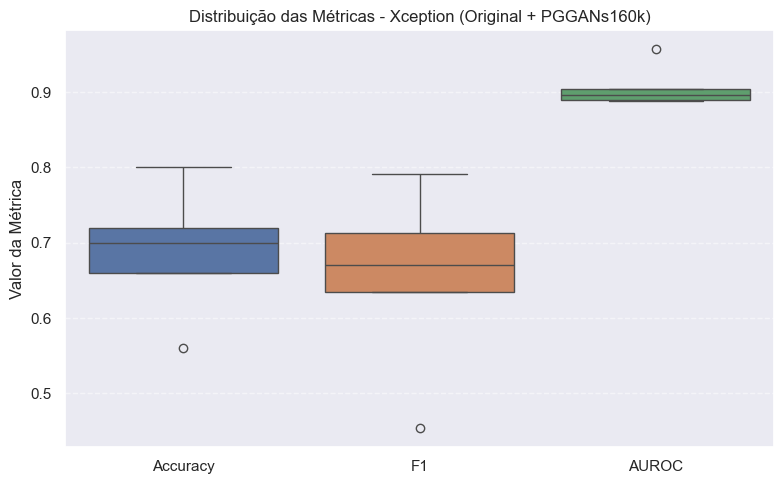

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 🔍 Converte lista de execuções em DataFrame
df_metrics_xception = pd.DataFrame(metrics_runs_xception)

# Seleciona apenas colunas relevantes
cols = ['Accuracy', 'F1', 'AUROC', 'Config', 'Run']
df_metrics_xception = df_metrics_xception[[c for c in cols if c in df_metrics_xception.columns]]

# 📈 Calcula média e desvio padrão
summary_xception = df_metrics_xception[['Accuracy', 'F1', 'AUROC']].agg(['mean', 'std']).T
summary_xception.columns = ['Mean', 'Std']
summary_xception = summary_xception.round(4)

print("\n📋 Desempenho do Xception (Original + PGGANs160k)")
print(summary_xception)

# 💾 Salva resumo em CSV
os.makedirs("Trained_Models", exist_ok=True)
summary_path_xception = "Trained_Models/Xception_summary_metrics.csv"
summary_xception.to_csv(summary_path_xception)
print(f"\nResumo salvo em: {summary_path_xception}")

# 📊 Visualização (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(data=df_metrics_xception[['Accuracy', 'F1', 'AUROC']])
plt.title("Distribuição das Métricas - Xception (Original + PGGANs160k)")
plt.ylabel("Valor da Métrica")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 💾 Salva gráfico
plt.savefig("Trained_Models/Xception_metrics_boxplot.png", dpi=300)
plt.show()


####  Custom CNN Training (from zero + mix)

In [30]:
# Treino Custom CNN (do zero + mix)
metrics_runs_cnn = []

title_cnn = "CustomCNN on Mixed PGGANs160k"
file_name_cnn = "Trained_Models/CustomCNN_training_history_plot_Mixed"

for i in range(n):
    print(f"Custom CNN Run {i+1}/{n}")
    trained_model_cnn, test_metrics_cnn, confusion_matrix_cnn = VGG_help.cv_train_and_evaluate_model(
        dataset_dir_train=dataset_dir_train,    # Treino original
        val_dataset_dir=val_dataset_dir,        # Validação
        test_dataset_dir=test_dataset_dir,      # Teste
        class_labels=class_labels,
        model_fn=VGG_help.custom_cnn,           # Função definida no VGG_help.py
        input_shape=input_shape,                # Ex.: (128, 128, 3)
        title=f"{title_cnn}_Run{i+1}",
        file_name=f"{file_name_cnn}_run{i+1}.png",
        cv=cv,
        epochs=epochs,
        batch_size=batch_size,
        num_classes=num_classes,
        use_mix=True
    )

    # Salvar modelo treinado
    trained_model_cnn.save(f'Trained_Models/{title_cnn}_run{i+1}.h5')

    # Adiciona métricas para análise posterior
    test_metrics_cnn['Config'] = 'Original+PGGANs'
    test_metrics_cnn['Run'] = i + 1
    metrics_runs_cnn.append(test_metrics_cnn)

    print(f"Custom CNN Run {i+1} Metrics: {test_metrics_cnn}")

# Análise final Custom CNN
df_metrics_cnn, comparison_cnn = VGG_help.analyze_performance(metrics_runs_cnn, output_dir='Trained_Models')


Custom CNN Run 1/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 24s 2s/step - loss: 2.0982 - accuracy: 0.6567 - val_loss: 2.1218 - val_accuracy: 0.5400
Epoch 2/5
10/10 [==============================] - 18s 2s/step - loss: 1.6235 - accuracy: 0.7700 - val_loss: 1.5791 - val_accuracy: 0.5600
Epoch 3/5
10/10 [==============================] - 24s 2s/step - loss: 1.1830 - accuracy: 0.8567 - val_loss: 1.1384 - val_accuracy: 0.8000
Epoch 4/5
10/10 [==============================] - 16s 2s/step - loss: 0.9541 - accuracy: 0.9000 - val_loss: 0.9515 - val_accuracy: 0.9000
Epoch 5/5
10/10 [==============================] - 16s 2s/step - loss: 0.8689 - accuracy: 0.9167 - val_loss: 0.9867 - val_accuracy: 0.8600
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 1]
Debug VGG: len(X_val) = 50, shape = (50, 128, 128, 3)


c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Custom CNN Run 1 Metrics: {'Accuracy': 0.68, 'F1': 0.6434937611408199, 'AUROC': 0.9024, 'Config': 'Original+PGGANs', 'Run': 1}
Custom CNN Run 2/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 20s 2s/step - loss: 2.3334 - accuracy: 0.6267 - val_loss: 2.0364 - val_accuracy: 0.5600
Epoch 2/5
10/10 [==============================] - 16s 2s/step - loss: 1.3536 - accuracy: 0.8300 - val_loss: 1.3478 - val_accuracy: 0.7200
Epoch 3/5
10/10 [==============================] - 17s 2s/step - loss: 1.2209 - accuracy: 0.8367 - val_loss: 0.8646 - val_accuracy: 0.9400
Epoch 4/5
10/10 [==============================] - 18s 2s/step - loss: 0.8826 - accuracy: 0.9167 - val_loss: 1.0174 - val_accuracy: 0.8600
Epoch 5/5
10/10 [==============================] - 16s 2s/step - loss: 0.8674 - accuracy: 0.9367 - val_loss: 0.8444 - val_accuracy: 0.9400
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes =

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Custom CNN Run 2 Metrics: {'Accuracy': 0.84, 'F1': 0.8397435897435898, 'AUROC': 0.888, 'Config': 'Original+PGGANs', 'Run': 2}
Custom CNN Run 3/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 20s 2s/step - loss: 2.7281 - accuracy: 0.6533 - val_loss: 1.3318 - val_accuracy: 0.7400
Epoch 2/5
10/10 [==============================] - 17s 2s/step - loss: 1.3115 - accuracy: 0.8067 - val_loss: 1.8404 - val_accuracy: 0.6400
Epoch 3/5
10/10 [==============================] - 16s 2s/step - loss: 1.2913 - accuracy: 0.8533 - val_loss: 1.0126 - val_accuracy: 0.8800
Epoch 4/5
10/10 [==============================] - 16s 2s/step - loss: 1.1387 - accuracy: 0.8867 - val_loss: 0.9391 - val_accuracy: 0.8800
Epoch 5/5
10/10 [==============================] - 16s 2s/step - loss: 0.8257 - accuracy: 0.9333 - val_loss: 0.8383 - val_accuracy: 0.9600
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = 

...

Custom CNN Run 3 Metrics: {'Accuracy': 0.82, 'F1': 0.8193496587715776, 'AUROC': 0.9184000000000001, 'Config': 'Original+PGGANs', 'Run': 3}
Custom CNN Run 4/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 23s 2s/step - loss: 3.1660 - accuracy: 0.5733 - val_loss: 6.5499 - val_accuracy: 0.5000
Epoch 2/5
10/10 [==============================] - 16s 2s/step - loss: 1.4222 - accuracy: 0.7633 - val_loss: 1.2074 - val_accuracy: 0.8000
Epoch 3/5
10/10 [==============================] - 16s 2s/step - loss: 1.2396 - accuracy: 0.8367 - val_loss: 1.3846 - val_accuracy: 0.6800
Epoch 4/5
10/10 [==============================] - 16s 2s/step - loss: 1.0982 - accuracy: 0.8567 - val_loss: 0.8829 - val_accuracy: 0.9400
Epoch 5/5
10/10 [==============================] - 16s 2s/step - loss: 1.0166 - accuracy: 0.8900 - val_loss: 0.8899 - val_accuracy: 0.9000
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, uniq

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Custom CNN Run 4 Metrics: {'Accuracy': 0.8, 'F1': 0.8, 'AUROC': 0.8976, 'Config': 'Original+PGGANs', 'Run': 4}
Custom CNN Run 5/5
Class labels: ['NORMAL', 'PNEUMONIA'], Num classes: 2
Epoch 1/5
10/10 [==============================] - 22s 2s/step - loss: 2.5138 - accuracy: 0.7033 - val_loss: 1.0349 - val_accuracy: 0.8200
Epoch 2/5
10/10 [==============================] - 16s 2s/step - loss: 1.2629 - accuracy: 0.8333 - val_loss: 1.1806 - val_accuracy: 0.7200
Epoch 3/5
10/10 [==============================] - 16s 2s/step - loss: 1.1526 - accuracy: 0.8400 - val_loss: 1.5503 - val_accuracy: 0.5800
Epoch 4/5
10/10 [==============================] - 16s 2s/step - loss: 0.9036 - accuracy: 0.9233 - val_loss: 0.8499 - val_accuracy: 0.9200
Epoch 5/5
10/10 [==============================] - 16s 2s/step - loss: 0.7952 - accuracy: 0.9633 - val_loss: 0.8512 - val_accuracy: 0.9600
Debug VGG: len(X_train) = 300, shape = (300, 128, 128, 3)
Debug VGG: len(y_train) = 300, unique classes = [0 1]
Debug VGG

c:\Users\ZINGA\Documents\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Custom CNN Run 5 Metrics: {'Accuracy': 0.78, 'F1': 0.7792051384985951, 'AUROC': 0.8768, 'Config': 'Original+PGGANs', 'Run': 5}
F1 Mean ± Std (Overall): 0.7764 ± 0.0776

Tabela Comparativa:
            Config  F1_Mean  F1_Std  AUROC_Mean
0  Original+PGGANs   0.7764  0.0776      0.8966
Tabela salva em: Trained_Models\performance_comparison.csv
Plot salvo em: Trained_Models\performance_comparison.png



📋 Desempenho do Custom CNN (Original + PGGANs160k)
            Mean     Std
Accuracy  0.7840  0.0623
F1        0.7764  0.0776
AUROC     0.8966  0.0156

Resumo salvo em: Trained_Models/CustomCNN_summary_metrics.csv


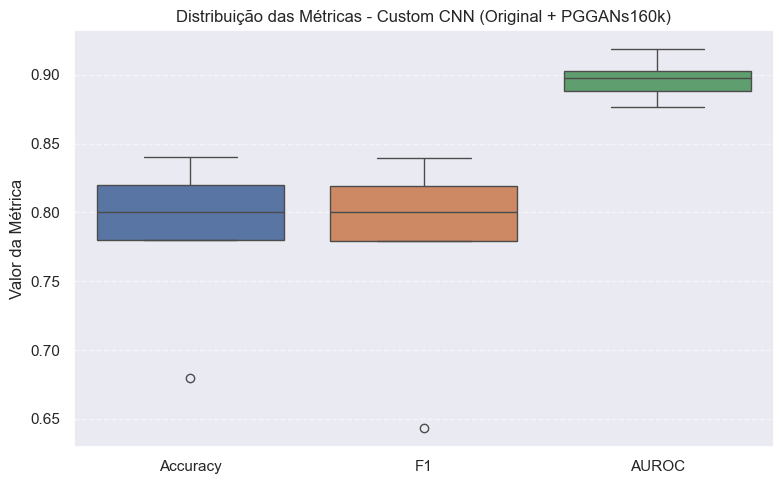

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 🔍 Converte lista de execuções em DataFrame
df_metrics_cnn = pd.DataFrame(metrics_runs_cnn)

# Seleciona apenas colunas relevantes
cols = ['Accuracy', 'F1', 'AUROC', 'Config', 'Run']
df_metrics_cnn = df_metrics_cnn[[c for c in cols if c in df_metrics_cnn.columns]]

# 📈 Calcula média e desvio padrão
summary_cnn = df_metrics_cnn[['Accuracy', 'F1', 'AUROC']].agg(['mean', 'std']).T
summary_cnn.columns = ['Mean', 'Std']
summary_cnn = summary_cnn.round(4)

print("\n📋 Desempenho do Custom CNN (Original + PGGANs160k)")
print(summary_cnn)

# 💾 Salva resumo em CSV
os.makedirs("Trained_Models", exist_ok=True)
summary_path_cnn = "Trained_Models/CustomCNN_summary_metrics.csv"
summary_cnn.to_csv(summary_path_cnn)
print(f"\nResumo salvo em: {summary_path_cnn}")

# 📊 Visualização (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(data=df_metrics_cnn[['Accuracy', 'F1', 'AUROC']])
plt.title("Distribuição das Métricas - Custom CNN (Original + PGGANs160k)")
plt.ylabel("Valor da Métrica")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 💾 Salva gráfico
plt.savefig("Trained_Models/CustomCNN_metrics_boxplot.png", dpi=300)
plt.show()



📋 Comparative Summary of All Models:
         Model  Accuracy_Mean  Accuracy_Std  F1_Mean  F1_Std  AUROC_Mean  \
0        VGG16          0.864        0.0167   0.8639  0.0166      0.9214   
1     ResNet50          0.828        0.0390   0.8275  0.0394      0.8835   
2  DenseNet121          0.660        0.1140   0.6032  0.1779      0.8282   
3     Xception          0.688        0.0879   0.6529  0.1254      0.9069   
4    CustomCNN          0.784        0.0623   0.7764  0.0776      0.8966   

   AUROC_Std  
0     0.0124  
1     0.0150  
2     0.1045  
3     0.0286  
4     0.0156  

✅ Arquivo salvo em: Trained_Models/AllModels_summary_comparison.csv


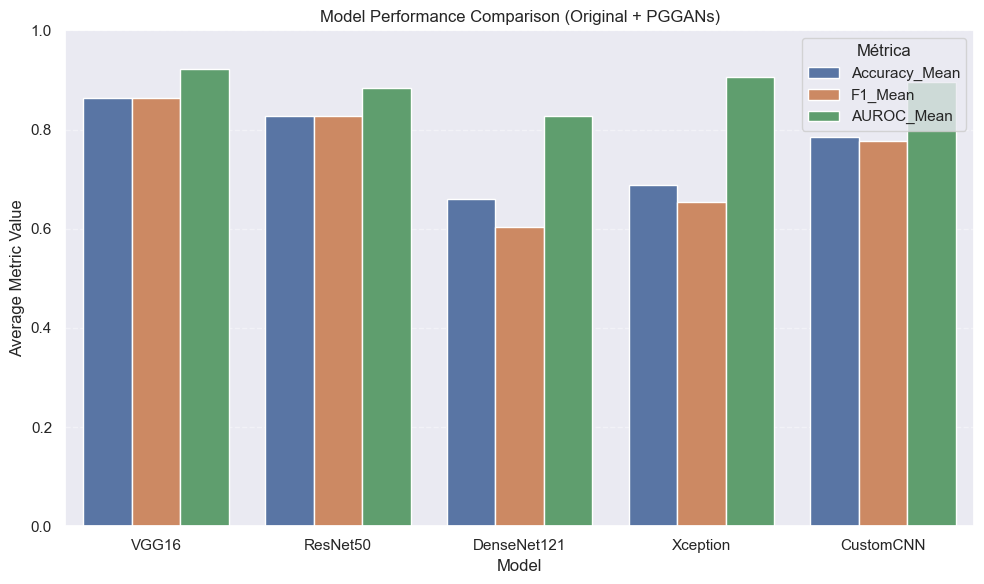

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ✅ Certifique-se de que cada df_metrics_* existe
all_results = {
    "VGG16": df_metrics_vgg,
    "ResNet50": df_metrics,
    "DenseNet121": df_metrics_densenet,
    "Xception": df_metrics_xception,
    "CustomCNN": df_metrics_cnn
}

# 🔹 Monta tabela resumo (média e desvio padrão)
summary_list = []
for model_name, df in all_results.items():
    if df is None or df.empty:
        print(f"Aviso ⚠️: Nenhum dado disponível para {model_name}.")
        continue
    
    metrics_mean = df[['Accuracy', 'F1', 'AUROC']].mean()
    metrics_std = df[['Accuracy', 'F1', 'AUROC']].std()
    summary_list.append({
        "Model": model_name,
        "Accuracy_Mean": round(metrics_mean['Accuracy'], 4),
        "Accuracy_Std": round(metrics_std['Accuracy'], 4),
        "F1_Mean": round(metrics_mean['F1'], 4),
        "F1_Std": round(metrics_std['F1'], 4),
        "AUROC_Mean": round(metrics_mean['AUROC'], 4),
        "AUROC_Std": round(metrics_std['AUROC'], 4)
    })

# 🔸 Cria DataFrame final de comparação
comparison_df = pd.DataFrame(summary_list)

# 💾 Salva em CSV
os.makedirs("Trained_Models", exist_ok=True)
comparison_path = "Trained_Models/AllModels_summary_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print("\n📋 Comparative Summary of All Models:")
print(comparison_df)
print(f"\n✅ Arquivo salvo em: {comparison_path}")

# 📈 Visualização (comparação por métrica)
plt.figure(figsize=(10,6))
melted_df = comparison_df.melt(id_vars=['Model'], value_vars=['Accuracy_Mean', 'F1_Mean', 'AUROC_Mean'],
                               var_name='Metric', value_name='Score')
sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric')
plt.title("Model Performance Comparison (Original + PGGANs)")
plt.ylabel("Average Metric Value")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Métrica')
plt.tight_layout()

# 💾 Salva gráfico
plt.savefig("Trained_Models/AllModels_comparison_barplot.png", dpi=300)
plt.show()
